In [36]:
import pandas as pd

In [37]:
df = pd.read_csv('../data/CMSData_sampled.csv')

# warning about mix type in column 12. we need to clean it

/var/folders/2m/c663cq1d2jqfxfb0gnwyxf0r0000gn/T/ipykernel_45722/682332089.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/CMSData_sampled.csv')


In [38]:
df.head()

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Gndr,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,...,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1124164496,Zirilli,Thomas,A,PT,M,I,7037 Manlius Center Rd,NaN,East Syracuse,...,"Evaluation for physical therapy, typically 30 ...",N,O,77,87.0,87,125.000000,98.120230,71.887011,74.188621
1,1922254275,Lipovic,Daniela,NaN,DO,F,I,199 Amsterdam Ave,NaN,New York,...,"New patient office or other outpatient visit, ...",N,O,15,15.0,15,375.333333,199.710667,178.628000,148.452000
2,1104803436,Rogoff,Michael,A,M.D.,M,I,4302 Alton Rd,Suite 300,Miami Beach,...,Review by radiologist of additional artery image,N,O,16,39.0,22,219.333333,100.618462,80.323333,78.953590
3,1871576157,Manda,Timothy,J,MD,M,I,100 South Ashley Drive,Suite 1500,Tampa,...,Screening mammography,N,F,140,140.0,140,259.000000,36.483214,36.483214,36.290000
4,1124360359,Shaw,Amy,L,MD,F,I,525 E. 68th St.,Payson 2,New York,...,"New patient office or other outpatient visit, ...",N,F,14,14.0,14,660.714286,213.283571,133.610000,114.258571


In [39]:
df[df.columns[12]].map(type).value_counts()

Rndrng_Prvdr_Zip5
<class 'int'>    259895
<class 'str'>     32768
Name: count, dtype: int64

In [40]:
df.columns.to_list()

['Rndrng_NPI',
 'Rndrng_Prvdr_Last_Org_Name',
 'Rndrng_Prvdr_First_Name',
 'Rndrng_Prvdr_MI',
 'Rndrng_Prvdr_Crdntls',
 'Rndrng_Prvdr_Gndr',
 'Rndrng_Prvdr_Ent_Cd',
 'Rndrng_Prvdr_St1',
 'Rndrng_Prvdr_St2',
 'Rndrng_Prvdr_City',
 'Rndrng_Prvdr_State_Abrvtn',
 'Rndrng_Prvdr_State_FIPS',
 'Rndrng_Prvdr_Zip5',
 'Rndrng_Prvdr_RUCA',
 'Rndrng_Prvdr_RUCA_Desc',
 'Rndrng_Prvdr_Cntry',
 'Rndrng_Prvdr_Type',
 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
 'HCPCS_Cd',
 'HCPCS_Desc',
 'HCPCS_Drug_Ind',
 'Place_Of_Srvc',
 'Tot_Benes',
 'Tot_Srvcs',
 'Tot_Bene_Day_Srvcs',
 'Avg_Sbmtd_Chrg',
 'Avg_Mdcr_Alowd_Amt',
 'Avg_Mdcr_Pymt_Amt',
 'Avg_Mdcr_Stdzd_Amt']

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292663 entries, 0 to 292662
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Rndrng_NPI                     292663 non-null  int64  
 1   Rndrng_Prvdr_Last_Org_Name     292663 non-null  object 
 2   Rndrng_Prvdr_First_Name        276469 non-null  object 
 3   Rndrng_Prvdr_MI                192087 non-null  object 
 4   Rndrng_Prvdr_Crdntls           261550 non-null  object 
 5   Rndrng_Prvdr_Gndr              276470 non-null  object 
 6   Rndrng_Prvdr_Ent_Cd            292663 non-null  object 
 7   Rndrng_Prvdr_St1               292663 non-null  object 
 8   Rndrng_Prvdr_St2               76506 non-null   object 
 9   Rndrng_Prvdr_City              292663 non-null  object 
 10  Rndrng_Prvdr_State_Abrvtn      292663 non-null  object 
 11  Rndrng_Prvdr_State_FIPS        292663 non-null  object 
 12  Rndrng_Prvdr_Zip5             

In [42]:
df.shape

(292663, 29)

In [43]:
profile = pd.DataFrame({
    "data_type": df.dtypes,
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})

profile

,data_type,missing,missing_%,unique_values
Rndrng_NPI,int64,0,0.00,229615
Rndrng_Prvdr_Last_Org_Name,object,0,0.00,87742
Rndrng_Prvdr_First_Name,object,16194,5.53,26153
Rndrng_Prvdr_MI,object,100576,34.37,31
Rndrng_Prvdr_Crdntls,object,31113,10.63,3954
Rndrng_Prvdr_Gndr,object,16193,5.53,2
Rndrng_Prvdr_Ent_Cd,object,0,0.00,2
Rndrng_Prvdr_St1,object,0,0.00,117600
Rndrng_Prvdr_St2,object,216157,73.86,15735
Rndrng_Prvdr_City,object,0,0.00,7757


In [44]:
df[ df['Rndrng_Prvdr_First_Name'].isna() ][[
    "Rndrng_Prvdr_Last_Org_Name",
    "Rndrng_Prvdr_First_Name",
    "Rndrng_Prvdr_MI",
    "Rndrng_Prvdr_Crdntls",
    "Rndrng_Prvdr_Ent_Cd",
    "Rndrng_Prvdr_Type"
]].head(10)

,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_Type
37,Publix Super Markets Inc,NaN,NaN,NaN,O,Centralized Flu
40,"Ham's Drugs & Gifts, Inc.",NaN,NaN,NaN,O,Pharmacy
44,Sweetwater Surgery Center Llc,NaN,NaN,NaN,O,Ambulatory Surgical Center
52,"Pennsylvania Cvs Pharmacy, L.L.C.",NaN,NaN,NaN,O,Mass Immunizer Roster Biller
55,Cvs Pharmacy Inc,NaN,NaN,NaN,O,Mass Immunizer Roster Biller
70,"Reston Surgery Center, Lp",NaN,NaN,NaN,O,Ambulatory Surgical Center
72,Hudson Pharmacy Group Inc,NaN,NaN,NaN,O,Mass Immunizer Roster Biller
82,Clarity Laboratories Llc,NaN,NaN,NaN,O,Clinical Laboratory
109,Q Labs Inc,NaN,NaN,NaN,O,Clinical Laboratory
119,Thrifty Payless Inc,NaN,NaN,NaN,O,Mass Immunizer Roster Biller


In [45]:
df[ df['Rndrng_Prvdr_Crdntls'].isna() ][[
    "Rndrng_Prvdr_Last_Org_Name", 
    "Rndrng_Prvdr_First_Name",
    "Rndrng_Prvdr_MI",
    "Rndrng_Prvdr_Crdntls",
    "Rndrng_Prvdr_Ent_Cd",
    "Rndrng_Prvdr_Type"
]].head(10)

,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_Type
30,Keesler-Young,Ashley,M,NaN,I,Physical Therapist in Private Practice
36,Keane,Brendan,NaN,NaN,I,Physical Therapist in Private Practice
37,Publix Super Markets Inc,NaN,NaN,NaN,O,Centralized Flu
40,"Ham's Drugs & Gifts, Inc.",NaN,NaN,NaN,O,Pharmacy
44,Sweetwater Surgery Center Llc,NaN,NaN,NaN,O,Ambulatory Surgical Center
52,"Pennsylvania Cvs Pharmacy, L.L.C.",NaN,NaN,NaN,O,Mass Immunizer Roster Biller
55,Cvs Pharmacy Inc,NaN,NaN,NaN,O,Mass Immunizer Roster Biller
57,Jin,Dugho,NaN,NaN,I,Diagnostic Radiology
70,"Reston Surgery Center, Lp",NaN,NaN,NaN,O,Ambulatory Surgical Center
72,Hudson Pharmacy Group Inc,NaN,NaN,NaN,O,Mass Immunizer Roster Biller


In [46]:
df[df["Rndrng_Prvdr_Crdntls"].isna()]["Rndrng_Prvdr_Ent_Cd"].value_counts()

Rndrng_Prvdr_Ent_Cd
O    16193
I    14920
Name: count, dtype: int64

In [47]:
pd.crosstab(
    df["Rndrng_Prvdr_Ent_Cd"],
    df["Rndrng_Prvdr_Crdntls"].isna()
)

Rndrng_Prvdr_Crdntls,False,True
Rndrng_Prvdr_Ent_Cd,,
I,261550,14920
O,0,16193


In [48]:
Missing_provider_Credentials  = df[
    (df['Rndrng_Prvdr_Crdntls'].isnull()) &
    (df['Rndrng_Prvdr_Ent_Cd'] == 'I')
]

Missing_provider_Credentials['Rndrng_Prvdr_Type'].value_counts().head(10)

Rndrng_Prvdr_Type
Nurse Practitioner                               2862
Physical Therapist in Private Practice           1574
Physician Assistant                              1462
Diagnostic Radiology                             1277
Internal Medicine                                1121
Family Practice                                   800
Emergency Medicine                                476
Certified Registered Nurse Anesthetist (CRNA)     460
Cardiology                                        333
Anesthesiology                                    292
Name: count, dtype: int64

In [49]:
df = df.drop(columns = ['Rndrng_Prvdr_St2'])

In [52]:
'Rndrng_Prvdr_St2' in df.columns

# Street Address 2 was removed because 73.86% of values were missing 
#and the field was not relevant to the project's provider utilization, cost, and payment analysis.

False

In [53]:
df[
    df["Rndrng_Prvdr_RUCA"].isna() |
    df["Rndrng_Prvdr_RUCA_Desc"].isna()
][[
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_City",
    "Rndrng_Prvdr_Zip5",
    "Rndrng_Prvdr_RUCA",
    "Rndrng_Prvdr_RUCA_Desc"
]].head(20)

,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_City,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc
319,ZZ,Apo,9175,NaN,NaN
2962,ZZ,Rehovot,76610,NaN,NaN
3069,DC,Washington,20307,NaN,NaN
3118,CT,Farmington,6030,NaN,NaN
3957,CT,Hartford,6102,NaN,NaN
4074,GU,Tamuning,98913,NaN,NaN
4946,MA,Palmer,1016,NaN,NaN
5772,CT,Mansfield Center,6250,NaN,NaN
6663,CT,Farmington,6030,NaN,NaN
7420,CT,Farmington,6030,NaN,NaN


In [55]:
df.duplicated().sum()

np.int64(0)

In [57]:
df = df.drop( columns = ['Rndrng_Prvdr_Zip5'])

In [60]:
'Rndrng_Prvdr_Zip5' in df.columns

#ZIP5 is not important for our core business question

False

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292663 entries, 0 to 292662
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Rndrng_NPI                     292663 non-null  int64  
 1   Rndrng_Prvdr_Last_Org_Name     292663 non-null  object 
 2   Rndrng_Prvdr_First_Name        276469 non-null  object 
 3   Rndrng_Prvdr_MI                192087 non-null  object 
 4   Rndrng_Prvdr_Crdntls           261550 non-null  object 
 5   Rndrng_Prvdr_Gndr              276470 non-null  object 
 6   Rndrng_Prvdr_Ent_Cd            292663 non-null  object 
 7   Rndrng_Prvdr_St1               292663 non-null  object 
 8   Rndrng_Prvdr_City              292663 non-null  object 
 9   Rndrng_Prvdr_State_Abrvtn      292663 non-null  object 
 10  Rndrng_Prvdr_State_FIPS        292663 non-null  object 
 11  Rndrng_Prvdr_RUCA              292329 non-null  float64
 12  Rndrng_Prvdr_RUCA_Desc        

In [83]:
pd.set_option("display.float_format", "{:,.2f}".format)

numeric_columns = [
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Bene_Day_Srvcs",
    "Avg_Sbmtd_Chrg",
    "Avg_Mdcr_Alowd_Amt",
    "Avg_Mdcr_Pymt_Amt",
    "Avg_Mdcr_Stdzd_Amt"
]
df[numeric_columns].describe()

,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
count,"292,663.00","292,663.00","292,663.00","292,663.00","292,663.00","292,663.00","292,663.00"
mean,83.40,273.65,131.65,400.16,105.32,82.20,81.30
std,"1,182.38","8,973.53","1,561.36","1,401.89",334.35,266.91,270.08
min,11.00,11.00,11.00,0.00,0.00,0.00,0.00
25%,17.00,20.00,20.00,69.56,27.38,21.40,19.56
50%,31.00,42.00,39.00,167.00,68.54,52.30,52.91
75%,71.00,114.00,102.00,343.00,120.70,89.13,88.44
max,"455,358.00","3,643,111.00","455,392.00","99,999.99","52,799.05","42,147.71","41,679.06"


In [68]:
import matplotlib.pyplot as plt

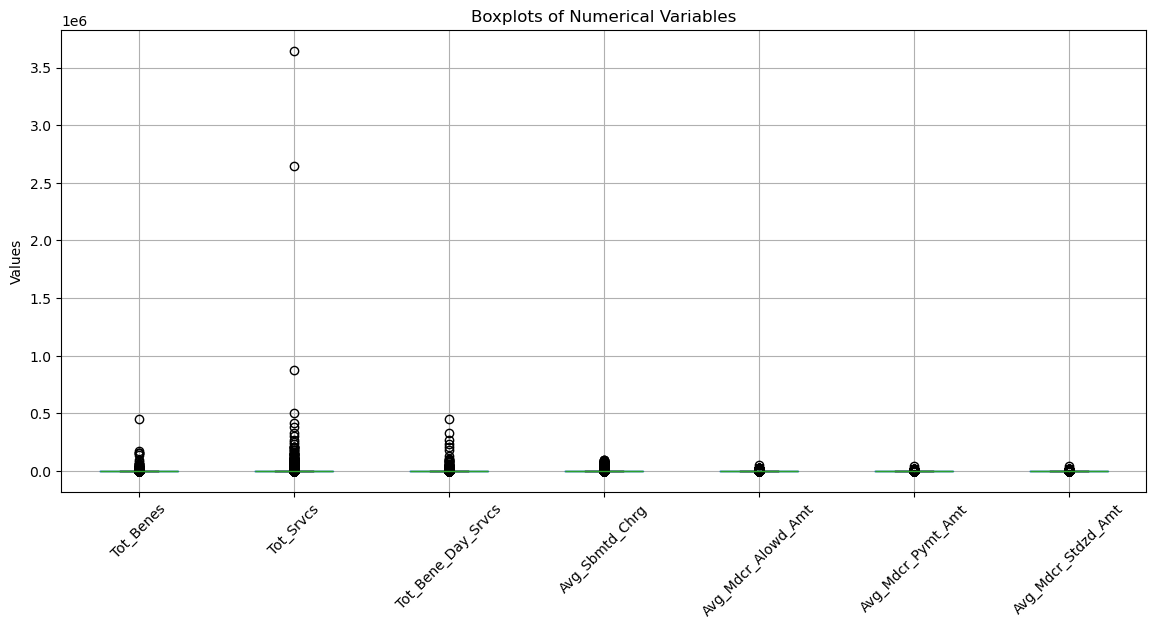

In [81]:
df[numeric_columns].boxplot(figsize=(14, 6), rot=45)

plt.title("Boxplots of Numerical Variables")
plt.ylabel("Values")
plt.show()


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292663 entries, 0 to 292662
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Rndrng_NPI                     292663 non-null  int64  
 1   Rndrng_Prvdr_Last_Org_Name     292663 non-null  object 
 2   Rndrng_Prvdr_First_Name        276469 non-null  object 
 3   Rndrng_Prvdr_MI                192087 non-null  object 
 4   Rndrng_Prvdr_Crdntls           261550 non-null  object 
 5   Rndrng_Prvdr_Gndr              276470 non-null  object 
 6   Rndrng_Prvdr_Ent_Cd            292663 non-null  object 
 7   Rndrng_Prvdr_St1               292663 non-null  object 
 8   Rndrng_Prvdr_City              292663 non-null  object 
 9   Rndrng_Prvdr_State_Abrvtn      292663 non-null  object 
 10  Rndrng_Prvdr_State_FIPS        292663 non-null  object 
 11  Rndrng_Prvdr_RUCA              292329 non-null  float64
 12  Rndrng_Prvdr_RUCA_Desc        

In [86]:
df.to_csv('../data/Cleaned_CMS_data.csv', index = False)